<a href="https://colab.research.google.com/github/keerthanarbsc24-debug/Deep_learning/blob/main/Temperature%20Time-Series%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name** : Keerthana R

**USN** :  1RUA24SCS0048

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving temperature_timeseries_dataset.csv to temperature_timeseries_dataset.csv


In [ ]:
df = pd.read_csv("temperature_timeseries_dataset.csv")

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

print("First 5 records:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nDataset information:")
df.info()

First 5 records:
        Date  Temperature
0 2023-01-01       25.397
1 2023-01-02       25.429
2 2023-01-03       26.579
3 2023-01-04       27.764
4 2023-01-05       26.793

Dataset shape:
(1000, 2)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1000 non-null   datetime64[ns]
 1   Temperature  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.8 KB


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Date           0
Temperature    0
dtype: int64


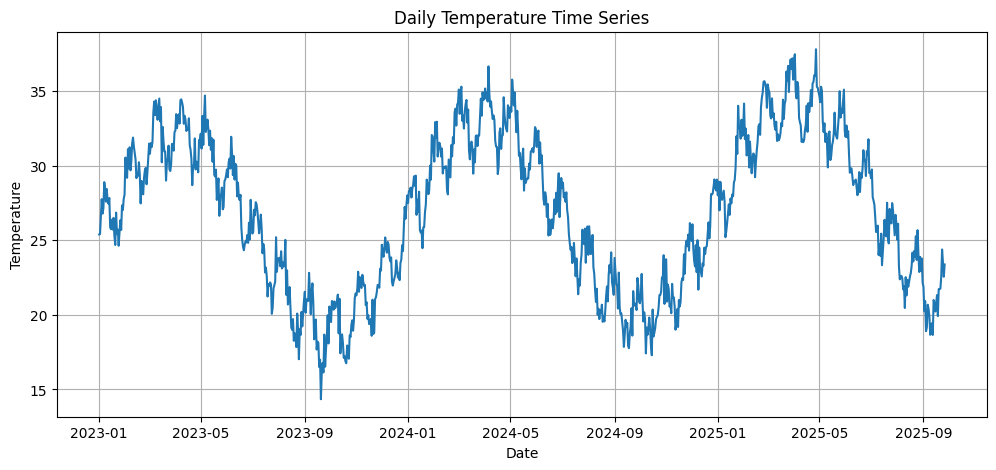

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Temperature"]
)

plt.title("Daily Temperature Time Series")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.grid(True)

plt.show()

In [ ]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df[["Temperature"]]
)

print("Normalized data shape:", scaled_data.shape)

Normalized data shape: (1000, 1)


In [ ]:
LOOK_BACK = 30

def create_sequences(data, look_back):

    X = []
    y = []

    for i in range(len(data) - look_back):

        X.append(
            data[i:i + look_back, 0]
        )

        y.append(
            data[i + look_back, 0]
        )

    return np.array(X), np.array(y)


X, y = create_sequences(
    scaled_data,
    LOOK_BACK
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (970, 30)
y shape: (970,)


In [ ]:
train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

Training samples: (776, 30)
Testing samples : (194, 30)


In [ ]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (776, 30, 1)
X_test shape: (194, 30, 1)


In [ ]:
def build_rnn():

    model = Sequential([
        SimpleRNN(
            64,
            input_shape=(LOOK_BACK, 1)
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [ ]:
def build_lstm():

    model = Sequential([
        LSTM(
            64,
            input_shape=(LOOK_BACK, 1)
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [ ]:
def build_gru():

    model = Sequential([
        GRU(
            64,
            input_shape=(LOOK_BACK, 1)
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [ ]:
def train_and_evaluate(model, model_name):

    print("\n" + "=" * 60)
    print("Training:", model_name)
    print("=" * 60)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.10,
        callbacks=[early_stop],
        verbose=1
    )

    end_time = time.time()

    training_time = end_time - start_time

    # Prediction
    predictions = model.predict(
        X_test,
        verbose=0
    )

    # Convert back to original temperature
    y_test_original = scaler.inverse_transform(
        y_test.reshape(-1, 1)
    )

    predictions_original = scaler.inverse_transform(
        predictions
    )

    # Metrics
    mae = mean_absolute_error(
        y_test_original,
        predictions_original
    )

    mse = mean_squared_error(
        y_test_original,
        predictions_original
    )

    rmse = np.sqrt(mse)

    print("\nMAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("Training Time:", training_time, "seconds")

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Training Time (sec)": training_time,
        "History": history,
        "Predictions": predictions_original,
        "Actual": y_test_original,
        "Model_Object": model
    }

In [ ]:
rnn_model = build_rnn()

rnn_result = train_and_evaluate(
    rnn_model,
    "Simple RNN"
)


Training: Simple RNN
Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0120 - val_loss: 0.0035
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0030 - val_loss: 0.0019
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

In [ ]:
lstm_model = build_lstm()

lstm_result = train_and_evaluate(
    lstm_model,
    "LSTM"
)


Training: LSTM
Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0455 - val_loss: 0.0269
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0081 - val_loss: 0.0105
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0059 - val_loss: 0.0069
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0048 - val_loss: 0.0053
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0043 - val_loss: 0.0041
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0036 - val_loss: 0.0033
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0031 - val_loss: 0.0027
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0029 - val_loss: 0.0025
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0


MAE: 0.7573654633354896
MSE: 0.8740896599254748
RMSE: 0.9349276228272833
Training Time: 23.917418003082275 seconds


In [ ]:
gru_model = build_gru()

gru_result = train_and_evaluate(
    gru_model,
    "GRU"
)


Training: GRU
Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0823 - val_loss: 0.0071
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0084 - val_loss: 0.0029
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0036 - val_loss: 0.0029
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0


MAE: 0.7916426302723049
MSE: 0.9326375454144684
RMSE: 0.9657316114814035
Training Time: 69.36693859100342 seconds


In [ ]:
results = pd.DataFrame([

    {
        "Model": rnn_result["Model"],
        "MAE": rnn_result["MAE"],
        "MSE": rnn_result["MSE"],
        "RMSE": rnn_result["RMSE"],
        "Training Time (sec)": rnn_result["Training Time (sec)"]
    },

    {
        "Model": lstm_result["Model"],
        "MAE": lstm_result["MAE"],
        "MSE": lstm_result["MSE"],
        "RMSE": lstm_result["RMSE"],
        "Training Time (sec)": lstm_result["Training Time (sec)"]
    },

    {
        "Model": gru_result["Model"],
        "MAE": gru_result["MAE"],
        "MSE": gru_result["MSE"],
        "RMSE": gru_result["RMSE"],
        "Training Time (sec)": gru_result["Training Time (sec)"]
    }

])

print("=" * 70)
print("PERFORMANCE COMPARISON")
print("=" * 70)

print(results.to_string(index=False))

PERFORMANCE COMPARISON
     Model      MAE      MSE     RMSE  Training Time (sec)
Simple RNN 0.854230 1.112368 1.054689            10.167305
      LSTM 0.757365 0.874090 0.934928            23.917418
       GRU 0.791643 0.932638 0.965732            69.366939


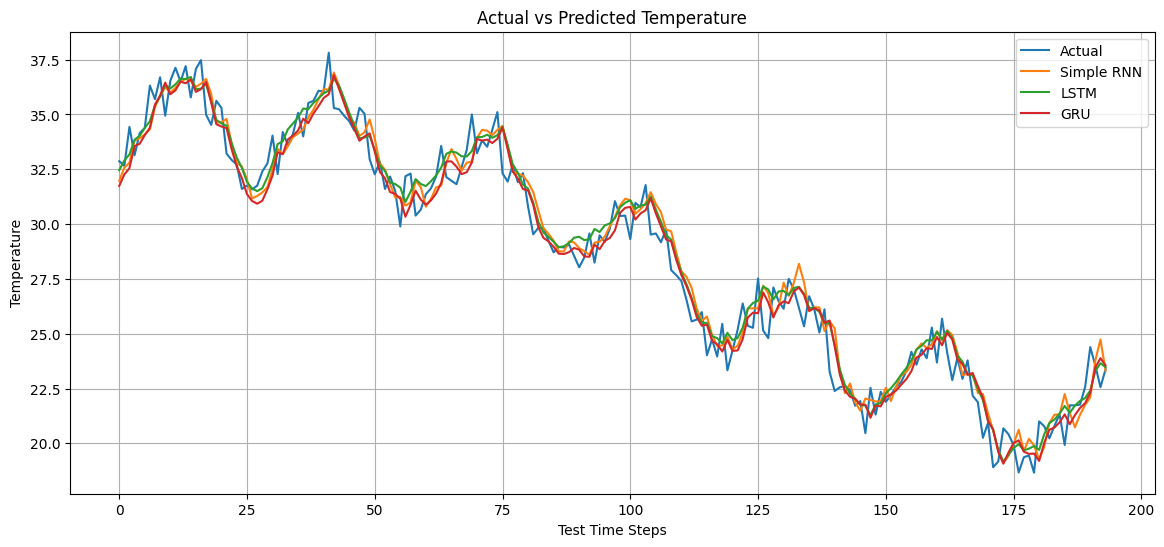

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    rnn_result["Actual"],
    label="Actual"
)

plt.plot(
    rnn_result["Predictions"],
    label="Simple RNN"
)

plt.plot(
    lstm_result["Predictions"],
    label="LSTM"
)

plt.plot(
    gru_result["Predictions"],
    label="GRU"
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Test Time Steps")
plt.ylabel("Temperature")

plt.legend()
plt.grid(True)

plt.show()

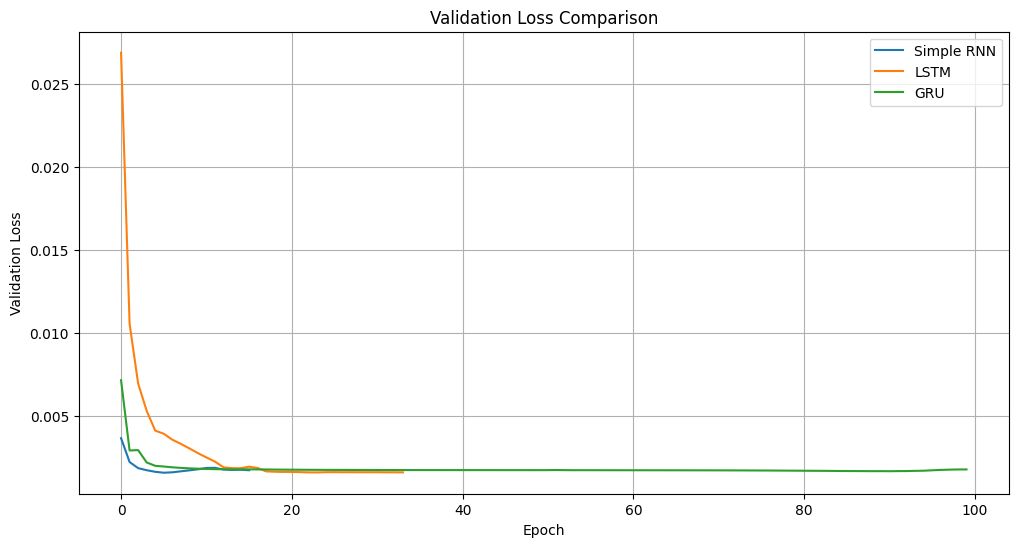

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    rnn_result["History"].history["val_loss"],
    label="Simple RNN"
)

plt.plot(
    lstm_result["History"].history["val_loss"],
    label="LSTM"
)

plt.plot(
    gru_result["History"].history["val_loss"],
    label="GRU"
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_model = results.loc[
    results["RMSE"].idxmin()
]

print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Model :", best_model["Model"])

print(
    "RMSE :",
    round(best_model["RMSE"], 4)
)

print(
    "MAE :",
    round(best_model["MAE"], 4)
)

print(
    "MSE :",
    round(best_model["MSE"], 4)
)

print(
    "Training Time :",
    round(best_model["Training Time (sec)"], 2),
    "seconds"
)


BEST MODEL
Model : LSTM
RMSE : 0.9349
MAE : 0.7574
MSE : 0.8741
Training Time : 23.92 seconds


In [ ]:
df.to_csv(
    "temperature_timeseries_dataset.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
rnn_model.save("simple_rnn_model.keras")
lstm_model.save("lstm_model.keras")
gru_model.save("gru_model.keras")

print("All models saved successfully!")

All models saved successfully!
